In [1]:
import os
import json
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F

class CustomCOCODataset(Dataset):
    def __init__(self, root_dir, annotation_file):
        """
        Args:
            root_dir (str): Path to the directory containing the images (e.g., 'train/').
            annotation_file (str): Path to the COCO JSON annotation file.
        """
        self.root_dir = root_dir
        
        # Load the JSON file
        with open(annotation_file, 'r') as f:
            self.coco_data = json.load(f)
        
        self.images = self.coco_data['images']
        self.annotations = self.coco_data['annotations']
        
        # Map each image ID to its corresponding annotations for faster lookup
        self.img_to_anns = {}
        for ann in self.annotations:
            img_id = ann['image_id']
            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_id = img_info['id']
        
        # 1. Load the Image
        img_path = os.path.join(self.root_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")
        image = F.to_tensor(image) # Converts to [C, H, W] and normalizes to 0-1
        
        # 2. Get Annotations for this image
        anns = self.img_to_anns.get(img_id, [])
        
        boxes = []
        labels = []
        areas = []
        iscrowd = []
        
        for ann in anns:
            # COCO format: [x_min, y_min, width, height]
            x_min, y_min, w, h = ann['bbox']
            
            # Convert to Faster R-CNN format: [x_min, y_min, x_max, y_max]
            x_max = x_min + w
            y_max = y_min + h
            
            boxes.append([x_min, y_min, x_max, y_max])
            labels.append(ann['category_id']) 
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0)) # Default to 0 if not present
            
        # 3. Convert lists to PyTorch Tensors
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            areas = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)
        else:
            # Handle images with no objects (background only)
            boxes = torch.empty((0, 4), dtype=torch.float32)
            labels = torch.empty((0,), dtype=torch.int64)
            areas = torch.empty((0,), dtype=torch.float32)
            iscrowd = torch.empty((0,), dtype=torch.int64)
            
        # 4. Construct the target dictionary
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([img_id])
        target["area"] = areas
        target["iscrowd"] = iscrowd
        
        return image, target

In [2]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [3]:
# Setup Paths (Adjust these if your JSON files are named differently)
train_dir = 'train/'
train_json = 'train/_annotations.coco.json'

valid_dir = 'valid/'
valid_json = 'valid/_annotations.coco.json'

# Create Dataset objects
dataset_train = CustomCOCODataset(root_dir=train_dir, annotation_file=train_json)
dataset_valid = CustomCOCODataset(root_dir=valid_dir, annotation_file=valid_json)

# Create DataLoaders
# Batch size of 4 is a safe starting point for an RTX 5060 depending on image resolution
data_loader_train = DataLoader(
    dataset_train, 
    batch_size=4, 
    shuffle=True, 
    num_workers=0, 
    collate_fn=collate_fn
)

data_loader_valid = DataLoader(
    dataset_valid, 
    batch_size=4, 
    shuffle=False, 
    num_workers=0, 
    collate_fn=collate_fn
)

print(f"Loaded {len(dataset_train)} training images and {len(dataset_valid)} validation images.")

Loaded 4290 training images and 409 validation images.


In [4]:
import json
import torch

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision # Added this missing import!
# 1. Dynamically find the number of classes from your JSON
with open('train/_annotations.coco.json', 'r') as f:
    coco_data = json.load(f)
    
# Count the categories in the JSON and add 1 for the background class
num_classes = len(coco_data['categories']) + 1 
print(f"Detected {num_classes - 1} custom classes. Total num_classes (including background): {num_classes}")

# 2. Initialize the Model
def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# Push the model to your RTX 5060
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Training on device: {device}")

model = get_model(num_classes).to(device)

# 3. Setup Optimizer and Mixed Precision (for the RTX 5060)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
scaler = torch.amp.GradScaler('cuda')

# 4. The Training Loop
num_epochs = 10 # Start with 10 to see how it runs, then increase later if needed

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    # Iterate through the dataloader we created in the previous step
    for batch_idx, (images, targets) in enumerate(data_loader_train):
        # Move images and targets to the GPU
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        optimizer.zero_grad()
        
        # Use Automatic Mixed Precision for faster training on the 5060
        with torch.amp.autocast('cuda'):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
        
        # Backpropagation
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += losses.item()
        
        # Print an update every 50 batches
        if batch_idx % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | Batch [{batch_idx}/{len(data_loader_train)}] | Loss: {losses.item():.4f}")
            
    print(f"--- Epoch {epoch+1} Completed | Average Loss: {epoch_loss/len(data_loader_train):.4f} ---")

print("Training Complete! Remember to save your model weights.")

# Save the trained weights to your hard drive
torch.save(model.state_dict(), "faster_rcnn_custom_weights.pth")

Detected 5 custom classes. Total num_classes (including background): 6
Training on device: cuda
Epoch [1/10] | Batch [0/1073] | Loss: 2.2222
Epoch [1/10] | Batch [50/1073] | Loss: 0.1678
Epoch [1/10] | Batch [100/1073] | Loss: 0.1459
Epoch [1/10] | Batch [150/1073] | Loss: 0.1097
Epoch [1/10] | Batch [200/1073] | Loss: 0.0675
Epoch [1/10] | Batch [250/1073] | Loss: 0.0906
Epoch [1/10] | Batch [300/1073] | Loss: 0.0839
Epoch [1/10] | Batch [350/1073] | Loss: 0.0792
Epoch [1/10] | Batch [400/1073] | Loss: 0.0646
Epoch [1/10] | Batch [450/1073] | Loss: 0.0795
Epoch [1/10] | Batch [500/1073] | Loss: 0.0710
Epoch [1/10] | Batch [550/1073] | Loss: 0.0783
Epoch [1/10] | Batch [600/1073] | Loss: 0.0647
Epoch [1/10] | Batch [650/1073] | Loss: 0.0660
Epoch [1/10] | Batch [700/1073] | Loss: 0.0658
Epoch [1/10] | Batch [750/1073] | Loss: 0.0881
Epoch [1/10] | Batch [800/1073] | Loss: 0.0687
Epoch [1/10] | Batch [850/1073] | Loss: 0.0600
Epoch [1/10] | Batch [900/1073] | Loss: 0.0569
Epoch [1/10] |

In [10]:
import os
import json
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Map Class IDs to Actual Names using your COCO JSON
with open('valid/_annotations.coco.json', 'r') as f:
    coco_data = json.load(f)

# Create a dictionary mapping: ID -> Name
# (Class 0 is always reserved for the Background)
id_to_name = {0: 'Background'}
for category in coco_data['categories']:
    id_to_name[category['id']] = category['name']

# 2. Create Output Folders for each class
output_base_dir = "Class_Predictions"
os.makedirs(output_base_dir, exist_ok=True)

for class_name in id_to_name.values():
    if class_name != 'Background':
        # This creates folders like: Class_Predictions/Dog, Class_Predictions/Cat, etc.
        os.makedirs(os.path.join(output_base_dir, class_name), exist_ok=True)

# 3. Model Setup (Assuming 'model' and 'device' are already in memory from previous cells)
model.eval()
confidence_threshold = 0.5

print(f"Generating visuals and saving to '{output_base_dir}/'...")

# 4. Loop through the validation data
# Note: We are just doing the first batch here so it doesn't take an hour. 
# To process your entire validation set, remove the 'break' statement at the very end.
for batch_idx, (images, targets) in enumerate(data_loader_valid):
    
    for img_idx, image in enumerate(images):
        image_tensor = image.to(device)
        
        # Get Predictions
        with torch.no_grad():
            predictions = model([image_tensor])
            
        pred_boxes = predictions[0]['boxes'].cpu()
        pred_scores = predictions[0]['scores'].cpu()
        pred_labels = predictions[0]['labels'].cpu()
        
        # Filter out low-confidence garbage predictions
        keep = pred_scores > confidence_threshold
        pred_boxes = pred_boxes[keep]
        pred_labels = pred_labels[keep]
        pred_scores = pred_scores[keep]
        
        # Find exactly which classes the model thinks are in this specific image
        unique_predicted_classes = torch.unique(pred_labels)
        
        # Convert image from PyTorch tensor to numpy array for Matplotlib
        img_plot = image.permute(1, 2, 0).numpy()
        
        # 5. Generate a separate image for EACH predicted class
        for cls_id in unique_predicted_classes:
            cls_id = cls_id.item()
            cls_name = id_to_name.get(cls_id, f"Unknown_Class_{cls_id}")
            
            if cls_name == 'Background':
                continue
                
            # Setup the canvas
            fig, ax = plt.subplots(1, figsize=(12, 12))
            ax.imshow(img_plot)
            
            # Filter the bounding boxes so we ONLY draw the current class
            class_mask = pred_labels == cls_id
            class_boxes = pred_boxes[class_mask]
            class_scores = pred_scores[class_mask]
            
            # Draw the boxes for this specific class
            for box, score in zip(class_boxes, class_scores):
                xmin, ymin, xmax, ymax = box
                
                # Draw the bounding box
                rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                                         linewidth=3, edgecolor='#00ff00', facecolor='none')
                ax.add_patch(rect)
                
                # Add a clean text label with the Name and Confidence %
                label_text = f'{cls_name}: {score*100:.1f}%'
                ax.text(xmin, ymin - 8, label_text, color='black', fontsize=12, fontweight='bold',
                        bbox=dict(facecolor='#00ff00', alpha=0.9, edgecolor='none', pad=2))
            
            plt.title(f"Model Predictions Isolated for: {cls_name}", fontsize=16, pad=10)
            plt.axis('off')
            
            # 6. Save the image to the correct folder
            filename = f"batch_{batch_idx}_img_{img_idx}.png"
            save_path = os.path.join(output_base_dir, cls_name, filename)
            
            plt.savefig(save_path, bbox_inches='tight', dpi=150)
            
            # CRITICAL: You must close the figure, otherwise Jupyter will store 
            # all of them in your RAM until your browser crashes.
            plt.close(fig) 
            
    # Remove this break statement if you want it to process every single image in your valid folder
    break 

print("Done! Go check the folder in your file explorer.")

Generating visuals and saving to 'Class_Predictions/'...
Done! Go check the folder in your file explorer.


In [12]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# 1. Initialize the metric calculator with class_metrics=True
metric = MeanAveragePrecision(class_metrics=True)

print("Starting evaluation on validation set...")
for images, targets in data_loader_valid:
    images = list(img.to(device) for img in images)
    
    # Move targets to CPU for the metric calculator
    targets_cpu = []
    for t in targets:
        targets_cpu.append({k: v.cpu() for k, v in t.items()})
    
    # Get model predictions
    with torch.no_grad():
        preds = model(images)
    
    # Move predictions to CPU
    preds_cpu = []
    for p in preds:
        preds_cpu.append({k: v.cpu() for k, v in p.items()})
        
    # Add batch to metric
    metric.update(preds_cpu, targets_cpu)

# 2. Compute the final scores
print("Computing metrics... (this might take a few seconds)")
results = metric.compute()

# 3. Print OVERALL Performance Metrics
print("\n" + "="*45)
print("        OVERALL PERFORMANCE METRICS")
print("="*45)
print(f"mAP (Mean Average Precision) : {results['map'].item():.4f}")
print(f"mAP at 50% IoU (Standard)    : {results['map_50'].item():.4f}")
print(f"mAP at 75% IoU (Strict)      : {results['map_75'].item():.4f}")
print("-" * 45)
print(f"mAR (Mean Average Recall)    : {results['mar_100'].item():.4f}") 

# 4. Print CLASS-WISE Performance Metrics
print("\n" + "="*55)
print("           CLASS-WISE PERFORMANCE METRICS")
print("="*55)
# Updated the table headers to reflect the available metrics
print(f"{'Class Name':<20} | {'mAP (Overall)':<15} | {'mAR (Recall)':<15}")
print("-" * 55)

# Extract ONLY the keys that torchmetrics actually generates per class
evaluated_classes = results['classes'].tolist()
map_per_class = results['map_per_class'].tolist()
mar_100_per_class = results['mar_100_per_class'].tolist()

# Loop through and print the rows 
for i, cls_id in enumerate(evaluated_classes):
    cls_id = int(cls_id)
    class_name = id_to_name.get(cls_id, f"Class ID {cls_id}")
    
    c_map = map_per_class[i]
    c_mar = mar_100_per_class[i]
    
    str_map = f"{c_map:.4f}" if c_map != -1 else "N/A"
    str_mar = f"{c_mar:.4f}" if c_mar != -1 else "N/A"

    print(f"{class_name:<20} | {str_map:<15} | {str_mar:<15}")

print("=" * 55)

Starting evaluation on validation set...
Computing metrics... (this might take a few seconds)

        OVERALL PERFORMANCE METRICS
mAP (Mean Average Precision) : 0.7916
mAP at 50% IoU (Standard)    : 0.9995
mAP at 75% IoU (Strict)      : 0.9716
---------------------------------------------
mAR (Mean Average Recall)    : 0.8289

           CLASS-WISE PERFORMANCE METRICS
Class Name           | mAP (Overall)   | mAR (Recall)   
-------------------------------------------------------
Brown Banana         | 0.7778          | 0.8180         
Green banana         | 0.7800          | 0.8190         
overripe banana      | 0.8216          | 0.8530         
yellow banana        | 0.7872          | 0.8257         


Matching bounding boxes and calculating Confusion Matrix...

Class Name           | Precision    | Recall       | F1-Score    
----------------------------------------------------------------------
Brown Banana         | 0.9901       | 1.0000       | 0.9950      
Green banana         | 1.0000       | 1.0000       | 1.0000      
overripe banana      | 1.0000       | 0.9700       | 0.9848      
yellow banana        | 0.9732       | 1.0000       | 0.9864      


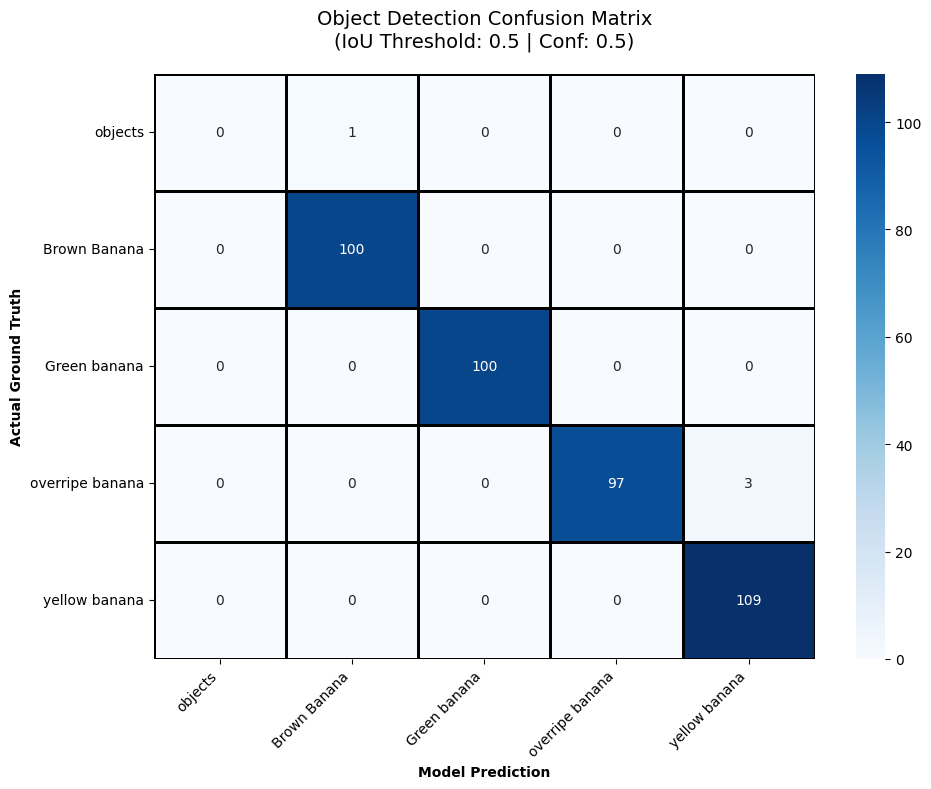

In [13]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision.ops import box_iou

# 1. Setup Parameters
iou_threshold = 0.5        # How much the boxes need to overlap to be a "match"
confidence_threshold = 0.5 # Ignore predictions with confidence below 50%

# Initialize an empty N x N matrix (where N is total classes, including background)
num_classes = len(id_to_name)
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

model.eval()
print("Matching bounding boxes and calculating Confusion Matrix...")

# 2. Evaluation Loop
with torch.no_grad():
    for images, targets in data_loader_valid:
        images = list(img.to(device) for img in images)
        preds = model(images)
        
        for target, pred in zip(targets, preds):
            gt_boxes = target['boxes'].cpu()
            gt_labels = target['labels'].cpu()
            
            pred_boxes = pred['boxes'].cpu()
            pred_labels = pred['labels'].cpu()
            pred_scores = pred['scores'].cpu()
            
            # Filter predictions by confidence
            keep = pred_scores > confidence_threshold
            pred_boxes = pred_boxes[keep]
            pred_labels = pred_labels[keep]
            
            # If no ground truths and no predictions, skip
            if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                continue
                
            # Calculate IoU between all GTs and all Preds -> Shape: [num_gt, num_preds]
            if len(gt_boxes) > 0 and len(pred_boxes) > 0:
                ious = box_iou(gt_boxes, pred_boxes)
            else:
                ious = torch.empty((len(gt_boxes), len(pred_boxes)))

            matched_preds = set()
            
            # 3. Match Predictions to Ground Truths
            for gt_idx in range(len(gt_boxes)):
                gt_label = gt_labels[gt_idx].item()
                
                # If there are no predictions at all, all GTs are False Negatives (Predicted as Background)
                if len(pred_boxes) == 0:
                    conf_matrix[gt_label][0] += 1
                    continue
                
                # Look only at predictions that haven't been matched yet
                valid_ious = ious[gt_idx].clone()
                valid_ious[list(matched_preds)] = -1 
                
                best_iou, best_pred_idx = valid_ious.max(dim=0)
                
                if best_iou > iou_threshold:
                    # Match found!
                    pred_label = pred_labels[best_pred_idx].item()
                    conf_matrix[gt_label][pred_label] += 1
                    matched_preds.add(best_pred_idx.item())
                else:
                    # No prediction overlapped enough. GT is a False Negative.
                    conf_matrix[gt_label][0] += 1
            
            # 4. Any unmatched predictions are False Positives (Predicted an object where there is none)
            for pred_idx in range(len(pred_boxes)):
                if pred_idx not in matched_preds:
                    pred_label = pred_labels[pred_idx].item()
                    conf_matrix[0][pred_label] += 1

# 5. Calculate Precision, Recall, and F1-Score from the matrix
print("\n" + "="*70)
print(f"{'Class Name':<20} | {'Precision':<12} | {'Recall':<12} | {'F1-Score':<12}")
print("-" * 70)

class_names = [id_to_name.get(i, f"Class {i}") for i in range(num_classes)]

for c in range(1, num_classes): # Skip Background (index 0) for these metrics
    tp = conf_matrix[c, c]
    fp = np.sum(conf_matrix[:, c]) - tp
    fn = np.sum(conf_matrix[c, :]) - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    class_name = class_names[c]
    print(f"{class_name:<20} | {precision:<12.4f} | {recall:<12.4f} | {f1:<12.4f}")

print("=" * 70)

# 6. Plot the Confusion Matrix
plt.figure(figsize=(10, 8))
# We add 0.5 to center the text, and use a nice color map
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black')

plt.title(f'Object Detection Confusion Matrix\n(IoU Threshold: {iou_threshold} | Conf: {confidence_threshold})', pad=20, fontsize=14)
plt.ylabel('Actual Ground Truth', fontweight='bold')
plt.xlabel('Model Prediction', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [1]:
import os
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================================
# 1. Setup Parameters and Output Directory
# ==========================================
output_dir = 'visualizations'
os.makedirs(output_dir, exist_ok=True)

# Minimum confidence to draw a prediction box (adjust to your optimal threshold)
conf_threshold = 0.5 

model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Creating '{output_dir}' directory and starting image generation...")

# ==========================================
# 2. Main Visualization Loop
# ==========================================
with torch.no_grad():
    # Iterate directly over the dataset (not the dataloader) to handle one image at a time
    for idx in range(len(dataset_test)):
        
        # Get image and ground truth target
        image, target = dataset_test[idx]
        
        # Move image to device and get predictions (requires adding a batch dimension)
        image_tensor = image.unsqueeze(0).to(device) 
        pred = model(image_tensor)[0]
        
        # Convert PyTorch image (C, H, W) to Matplotlib format (H, W, C)
        # We also clamp to [0, 1] just in case of slight normalization variations
        img_display = image.permute(1, 2, 0).cpu().numpy().clip(0, 1)
        
        # ==========================================
        # 3. Setup Side-by-Side Plot
        # ==========================================
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        
        # --- Left Side: Ground Truth ---
        axes[0].imshow(img_display)
        axes[0].set_title('Ground Truth (Gold)', fontsize=18, fontweight='bold', pad=15)
        axes[0].axis('off') # Hide axes for a cleaner look
        
        gt_boxes = target['boxes'].cpu()
        for box in gt_boxes:
            xmin, ymin, xmax, ymax = box
            width, height = xmax - xmin, ymax - ymin
            # Draw Gold Bounding Box
            rect = patches.Rectangle((xmin, ymin), width, height, 
                                     linewidth=3, edgecolor='gold', facecolor='none')
            axes[0].add_patch(rect)
            
        # --- Right Side: Model Predictions ---
        axes[1].imshow(img_display)
        axes[1].set_title(f'Model Predictions (White, Conf > {conf_threshold})', fontsize=18, fontweight='bold', pad=15)
        axes[1].axis('off')
        
        pred_boxes = pred['boxes'].cpu()
        pred_scores = pred['scores'].cpu()
        
        for box, score in zip(pred_boxes, pred_scores):
            if score > conf_threshold:
                xmin, ymin, xmax, ymax = box
                width, height = xmax - xmin, ymax - ymin
                # Draw White Bounding Box
                rect = patches.Rectangle((xmin, ymin), width, height, 
                                         linewidth=3, edgecolor='white', facecolor='none')
                axes[1].add_patch(rect)
                
                # Add a small black background behind the confidence score so it's readable
                axes[1].text(xmin, ymin - 6, f'{score:.2f}', color='white', 
                             fontsize=12, fontweight='bold', backgroundcolor='black')

        # ==========================================
        # 4. Save Image and Free Memory
        # ==========================================
        plt.tight_layout()
        save_path = os.path.join(output_dir, f'test_image_{idx:04d}.png')
        plt.savefig(save_path, bbox_inches='tight', dpi=150) # High DPI for paper quality
        plt.close(fig) # Critical: Closes the plot so you don't run out of RAM!
        
        # Print progress tracker
        if (idx + 1) % 10 == 0 or (idx + 1) == len(dataset_test):
            print(f"Processed and saved {idx + 1}/{len(dataset_test)} images...")

print("\nVisualization complete! Check the 'visualizations' folder for your side-by-side comparisons.")

NameError: name 'model' is not defined